# EM Carry Extension and G10 Comparison

This notebook extends the monthly 1M FX carry analysis from G10 to EM currencies using the downloaded Bloomberg spot and forward/NDF data. It builds a clean EM carry panel, then compares baseline carry portfolios for G10, EM ex-CNH, EM including CNH, and G10+EM.

No Bloomberg refetch is performed. The notebook uses the raw/processed files already saved by `src/bloomberg_data.py` and the G10 panel built in `01_build_core_carry_panel.ipynb`.


## Return and Carry Sign Convention

All spot and forward quotes are converted into USD per 1 unit of foreign currency. The one-month realized forward excess return is:

$$
r^{i}_{t+1} = \log(S^{i}_{t+1}) - \log(F^{i}_{t})
$$

where:

$$
S^{i}_{t+1}
$$

is next month-end spot in USD per foreign currency, and:

$$
F^{i}_{t}
$$

is the current 1M forward outright in USD per foreign currency.

The prompt's formula:

$$
\log(F^{i}_{t}) - \log(S^{i}_{t})
$$

is the forward premium in USD-per-foreign-currency terms. For a long-foreign carry ranking, high-yield currencies typically have forwards below spot in USD-per-foreign terms, so the economically natural carry signal is the negative of that premium:

$$
\text{carry}^{i}_{t} = \log(S^{i}_{t}) - \log(F^{i}_{t})
$$

This notebook stores both `forward_premium_1m = log(F) - log(S)` and `carry_signal_1m = log(S) - log(F)`. Strategies rank on `carry_signal_1m`, so high-carry currencies rank higher.


$$
r_{t+1} = \log(S_{t+1}) - \log(F_t) = r_{t+1} =  \underbrace{\log\left(\frac{S_t}{F_t}\right)}_{\text{carry signal}} + \underbrace{\log\left(\frac{S_{t+1}}{S_t}\right)}_{\text{spot log return}} 
$$​


In [1]:
from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 140)
pd.set_option("display.width", 200)


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start] + list(start.parents):
        if (candidate / "data" / "raw").exists() and (candidate / "theo" / "data" / "processed").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing data/raw and theo/data/processed.")

ROOT = find_project_root()
RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "theo" / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

EM_RAW_PATH = RAW_DIR / "em_fx_spot_forward_long.parquet"
G10_PANEL_PATH = PROCESSED_DIR / "g10_1m_carry_panel.parquet"
EM_PANEL_OUT = PROCESSED_DIR / "em_1m_carry_panel.parquet"
STRATEGY_RETURNS_OUT = PROCESSED_DIR / "em_carry_strategy_returns.parquet"
COMPARISON_OUT = PROCESSED_DIR / "g10_em_carry_comparison.parquet"

MONTHS_PER_YEAR = 12
ROLL_COST_BPS = [1, 2, 5, 10, 25, 50]

print(f"Project root: {ROOT}")
print(f"EM raw file: {EM_RAW_PATH}")
print(f"G10 panel: {G10_PANEL_PATH}")


Project root: /Users/theoli/Documents/Work/UChicago/Courses/36000_project_lab/BofA/repo
EM raw file: /Users/theoli/Documents/Work/UChicago/Courses/36000_project_lab/BofA/repo/data/raw/em_fx_spot_forward_long.parquet
G10 panel: /Users/theoli/Documents/Work/UChicago/Courses/36000_project_lab/BofA/repo/theo/data/processed/g10_1m_carry_panel.parquet


## EM Universe and Forward Convention Map

The EM spot tickers are USD pairs in Bloomberg's raw convention, usually local currency per USD. The notebook converts them to USD per foreign currency by taking the reciprocal.

Forwards and NDFs are not assumed to be outright rates. The mapping below selects simple 1M forward tickers where available and special NDF/root conventions otherwise. INR uses `IRN1M Curncy` because the simple `INR1M Curncy` ticker is unavailable in the downloaded data.


In [2]:
EM_CURRENCIES = ["MXN", "ZAR", "BRL", "KRW", "IDR", "MYR", "PHP", "CLP", "COP", "PEN", "SGD", "CNH", "INR", "THB", "PLN", "HUF", "TRY", "ILS"]

# Currency-specific point sizes are in raw quote units. They convert Bloomberg forward points into outright local-per-USD rates.
EM_CONFIG = {
    "MXN": {"forward_ticker": "MXN1M Curncy", "point_size": 0.0001, "note": "simple forward points"},
    "ZAR": {"forward_ticker": "ZAR1M Curncy", "point_size": 0.0001, "note": "simple forward points"},
    "BRL": {"forward_ticker": "BCN1M Curncy", "point_size": 0.0001, "note": "BRL NDF root BCN"},
    "KRW": {"forward_ticker": "KWO1M Curncy", "point_size": 1.0, "note": "KRW special/onshore root KWO"},
    "IDR": {"forward_ticker": "IHO1M Curncy", "point_size": 1.0, "note": "IDR special/onshore root IHO"},
    "MYR": {"forward_ticker": "MYR1M Curncy", "point_size": 0.0001, "note": "simple forward points"},
    "PHP": {"forward_ticker": "PPN1M Curncy", "point_size": 1.0, "note": "PHP NDF root PPN"},
    "CLP": {"forward_ticker": "CHN1M Curncy", "point_size": 1.0, "note": "CLP NDF root CHN"},
    "COP": {"forward_ticker": "CLN1M Curncy", "point_size": 1.0, "note": "COP NDF root CLN"},
    "PEN": {"forward_ticker": "PSN1M Curncy", "point_size": 0.0001, "note": "PEN NDF root PSN"},
    "SGD": {"forward_ticker": "SGD1M Curncy", "point_size": 0.0001, "note": "simple forward points"},
    "CNH": {"forward_ticker": "CNH1M Curncy", "point_size": 0.0001, "note": "CNH offshore simple forward points"},
    "INR": {"forward_ticker": "IRN1M Curncy", "point_size": 0.01, "note": "INR IRN convention used because INR1M is unavailable"},
    "THB": {"forward_ticker": "THB1M Curncy", "point_size": 0.01, "note": "simple forward points"},
    "PLN": {"forward_ticker": "PLN1M Curncy", "point_size": 0.0001, "note": "simple forward points"},
    "HUF": {"forward_ticker": "HUF1M Curncy", "point_size": 0.01, "note": "HUF points use 0.01 local units"},
    "TRY": {"forward_ticker": "TRY1M Curncy", "point_size": 0.0001, "note": "simple forward points"},
    "ILS": {"forward_ticker": "ILS1M Curncy", "point_size": 0.0001, "note": "simple forward points"},
}

config_table = pd.DataFrame([
    {"currency": ccy, "spot_ticker": f"{ccy} Curncy", "quote_direction": "local per USD; inverted to USD per currency", **EM_CONFIG[ccy]}
    for ccy in EM_CURRENCIES
])
display(config_table)


,currency,spot_ticker,quote_direction,forward_ticker,point_size,note
0,MXN,MXN Curncy,local per USD; inverted to USD per currency,MXN1M Curncy,0.0001,simple forward points
1,ZAR,ZAR Curncy,local per USD; inverted to USD per currency,ZAR1M Curncy,0.0001,simple forward points
2,BRL,BRL Curncy,local per USD; inverted to USD per currency,BCN1M Curncy,0.0001,BRL NDF root BCN
3,KRW,KRW Curncy,local per USD; inverted to USD per currency,KWO1M Curncy,1.0000,KRW special/onshore root KWO
4,IDR,IDR Curncy,local per USD; inverted to USD per currency,IHO1M Curncy,1.0000,IDR special/onshore root IHO
5,MYR,MYR Curncy,local per USD; inverted to USD per currency,MYR1M Curncy,0.0001,simple forward points
6,PHP,PHP Curncy,local per USD; inverted to USD per currency,PPN1M Curncy,1.0000,PHP NDF root PPN
7,CLP,CLP Curncy,local per USD; inverted to USD per currency,CHN1M Curncy,1.0000,CLP NDF root CHN
8,COP,COP Curncy,local per USD; inverted to USD per currency,CLN1M Curncy,1.0000,COP NDF root CLN
9,PEN,PEN Curncy,local per USD; inverted to USD per currency,PSN1M Curncy,0.0001,PEN NDF root PSN


## Load EM Spot and Forward Data

The loader uses only the saved long-format EM spot/forward file. Missing files or missing tickers are reported as diagnostics.


In [3]:
def read_long_parquet(path):
    if not path.exists():
        warnings.warn(f"Missing file: {path}")
        return pd.DataFrame(columns=["date", "ticker", "field", "value"])
    df = pd.read_parquet(path)
    needed = ["date", "ticker", "field", "value"]
    for col in needed:
        if col not in df.columns:
            raise ValueError(f"{path} missing required column {col}")
    df = df[needed].copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["ticker"] = df["ticker"].astype(str)
    df["field"] = df["field"].astype(str)
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    return df.dropna(subset=["date", "ticker", "field"])

em_long = read_long_parquet(EM_RAW_PATH)
em_last = em_long[em_long["field"].eq("PX_LAST")].copy()

available_tickers = set(em_long["ticker"].dropna().unique()) if not em_long.empty else set()
availability = []
for ccy in EM_CURRENCIES:
    spot_ticker = f"{ccy} Curncy"
    fwd_ticker = EM_CONFIG[ccy]["forward_ticker"]
    availability.append({
        "currency": ccy,
        "spot_ticker": spot_ticker,
        "forward_ticker": fwd_ticker,
        "spot_available": spot_ticker in available_tickers,
        "forward_available": fwd_ticker in available_tickers,
    })
availability = pd.DataFrame(availability)

display(pd.DataFrame([{"rows": len(em_long), "tickers": em_long["ticker"].nunique() if not em_long.empty else 0, "fields": ", ".join(sorted(em_long["field"].unique())) if not em_long.empty else ""}]))
display(availability)


,rows,tickers,fields
0,1393179,95,"PX_ASK, PX_BID, PX_LAST"


,currency,spot_ticker,forward_ticker,spot_available,forward_available
0,MXN,MXN Curncy,MXN1M Curncy,True,True
1,ZAR,ZAR Curncy,ZAR1M Curncy,True,True
2,BRL,BRL Curncy,BCN1M Curncy,True,True
3,KRW,KRW Curncy,KWO1M Curncy,True,True
4,IDR,IDR Curncy,IHO1M Curncy,True,True
5,MYR,MYR Curncy,MYR1M Curncy,True,True
6,PHP,PHP Curncy,PPN1M Curncy,True,True
7,CLP,CLP Curncy,CHN1M Curncy,True,True
8,COP,COP Curncy,CLN1M Curncy,True,True
9,PEN,PEN Curncy,PSN1M Curncy,True,True


## Quote Direction and Forward-Points Diagnostics

The table below compares raw spot levels and raw 1M forward ticker levels. For an outright forward, the forward level should be very close to spot. Most downloaded EM forward/NDF tickers are points-like, so the converted outright is:

$$
\text{forward outright raw}_t = \text{spot raw}_t + \text{forward points raw}_t \times \text{point size}
$$

The converted USD-per-currency forward is the reciprocal because the raw EM convention is local currency per USD.


In [4]:
def get_series(df, ticker):
    if df.empty:
        return pd.Series(dtype=float, name=ticker)
    s = (df[df["ticker"].eq(ticker)]
         .dropna(subset=["date"])
         .sort_values("date")
         .drop_duplicates(subset=["date"], keep="last")
         .set_index("date")["value"])
    s.name = ticker
    return pd.to_numeric(s, errors="coerce")


def classify_forward(spot, fwd):
    joined = pd.concat([spot.rename("spot_raw"), fwd.rename("forward_1m_raw")], axis=1).dropna()
    if len(joined) < 24:
        return "missing_or_short", joined
    ratio = (joined["forward_1m_raw"] / joined["spot_raw"]).replace([np.inf, -np.inf], np.nan)
    rel_diff = ((joined["forward_1m_raw"] - joined["spot_raw"]) / joined["spot_raw"]).replace([np.inf, -np.inf], np.nan)
    neg_share = (joined["forward_1m_raw"] < 0).mean()
    median_abs_rel = rel_diff.abs().median()
    median_ratio = ratio.median()
    if pd.notna(median_abs_rel) and neg_share == 0 and 0.98 <= median_ratio <= 1.02 and median_abs_rel <= 0.02:
        return "outright", joined
    if neg_share > 0 or (pd.notna(median_abs_rel) and median_abs_rel > 0.02):
        return "points-like", joined
    return "ambiguous", joined


def build_em_diagnostics():
    rows = []
    pair_data = {}
    for ccy in EM_CURRENCIES:
        spot_ticker = f"{ccy} Curncy"
        fwd_ticker = EM_CONFIG[ccy]["forward_ticker"]
        spot = get_series(em_last, spot_ticker)
        fwd = get_series(em_last, fwd_ticker)
        inferred, joined = classify_forward(spot, fwd)
        pair_data[ccy] = joined
        point_size = EM_CONFIG[ccy]["point_size"]
        if joined.empty:
            rows.append({"currency": ccy, "forward_ticker_used": fwd_ticker, "observations": 0, "inferred_forward_type": inferred, "data_quality_flag": "missing spot or forward"})
            continue
        ex = joined.dropna().iloc[-1]
        converted_raw = ex["forward_1m_raw"] if inferred == "outright" else ex["spot_raw"] + ex["forward_1m_raw"] * point_size
        econ_ok = bool(pd.notna(converted_raw) and converted_raw > 0 and abs(converted_raw / ex["spot_raw"] - 1.0) < 0.25)
        rows.append({
            "currency": ccy,
            "spot_ticker": spot_ticker,
            "forward_ticker_used": fwd_ticker,
            "observations": len(joined),
            "first_date": joined.index.min().date().isoformat(),
            "last_date": joined.index.max().date().isoformat(),
            "example_spot_level": ex["spot_raw"],
            "example_forward_raw_level": ex["forward_1m_raw"],
            "inferred_forward_type": inferred,
            "point_size_used": point_size if inferred != "outright" else np.nan,
            "converted_forward_outright_raw": converted_raw,
            "converted_forward_over_spot": converted_raw / ex["spot_raw"] if ex["spot_raw"] else np.nan,
            "economically_reasonable": econ_ok,
            "data_quality_flag": "ok" if econ_ok and inferred in ["points-like", "outright"] else "review conversion",
            "note": EM_CONFIG[ccy]["note"],
        })
    return pd.DataFrame(rows), pair_data

em_forward_diagnostics, em_pair_data = build_em_diagnostics()
display(em_forward_diagnostics)

review = em_forward_diagnostics[em_forward_diagnostics["data_quality_flag"].ne("ok")]
if not review.empty:
    warnings.warn("Some EM currencies have ambiguous or questionable forward conversion diagnostics. They remain in the panel but are flagged.")
    display(review)


,currency,spot_ticker,forward_ticker_used,observations,first_date,last_date,example_spot_level,example_forward_raw_level,inferred_forward_type,point_size_used,converted_forward_outright_raw,converted_forward_over_spot,economically_reasonable,data_quality_flag,note
0,MXN,MXN Curncy,MXN1M Curncy,5054,2007-01-02,2026-06-30,17.4877,460.500,points-like,0.0001,17.533750,1.002633,True,ok,simple forward points
1,ZAR,ZAR Curncy,ZAR1M Curncy,5079,2007-01-01,2026-06-30,16.3892,433.000,points-like,0.0001,16.432500,1.002642,True,ok,simple forward points
2,BRL,BRL Curncy,BCN1M Curncy,4869,2007-01-02,2026-06-30,5.1616,391.080,points-like,0.0001,5.200708,1.007577,True,ok,BRL NDF root BCN
3,KRW,KRW Curncy,KWO1M Curncy,4562,2007-01-02,2026-06-30,1549.2500,-1.050,points-like,1.0000,1548.200000,0.999322,True,ok,KRW special/onshore root KWO
4,IDR,IDR Curncy,IHO1M Curncy,4783,2007-01-02,2026-06-30,17882.0000,47.500,points-like,1.0000,17929.500000,1.002656,True,ok,IDR special/onshore root IHO
5,MYR,MYR Curncy,MYR1M Curncy,4742,2007-01-04,2026-06-30,4.0840,-26.560,points-like,0.0001,4.081344,0.999350,True,ok,simple forward points
6,PHP,PHP Curncy,PPN1M Curncy,4285,2007-01-03,2026-06-30,61.3560,0.061,points-like,1.0000,61.417000,1.000994,True,ok,PHP NDF root PPN
7,CLP,CLP Curncy,CHN1M Curncy,4773,2007-01-02,2026-06-30,922.3100,-0.500,points-like,1.0000,921.810000,0.999458,True,ok,CLP NDF root CHN
8,COP,COP Curncy,CLN1M Curncy,4790,2007-01-02,2026-06-30,3418.2300,23.250,points-like,1.0000,3441.480000,1.006802,True,ok,COP NDF root CLN
9,PEN,PEN Curncy,PSN1M Curncy,4754,2007-01-02,2026-06-30,3.4087,44.000,points-like,0.0001,3.413100,1.001291,True,ok,PEN NDF root PSN


## Build the Clean EM 1M Carry Panel

All raw EM spot and forward outrights are local currency per USD, so the notebook converts them into USD per foreign currency with a reciprocal. The realized return and carry signal are computed in logs.


In [5]:
def build_daily_em_panel():
    rows = []
    diag_lookup = em_forward_diagnostics.set_index("currency").to_dict("index") if not em_forward_diagnostics.empty else {}
    for ccy in EM_CURRENCIES:
        joined = em_pair_data.get(ccy, pd.DataFrame()).copy()
        diag = diag_lookup.get(ccy, {})
        inferred = diag.get("inferred_forward_type", "missing_or_short")
        point_size = EM_CONFIG[ccy]["point_size"]
        if joined.empty:
            continue
        if inferred == "outright":
            joined["forward_outright_raw"] = joined["forward_1m_raw"]
        elif inferred in ["points-like", "ambiguous"]:
            joined["forward_outright_raw"] = joined["spot_raw"] + joined["forward_1m_raw"] * point_size
        else:
            joined["forward_outright_raw"] = np.nan
        joined["spot_usd_per_ccy"] = 1.0 / joined["spot_raw"]
        joined["forward_1m_usd_per_ccy"] = 1.0 / joined["forward_outright_raw"]
        joined = joined.replace([np.inf, -np.inf], np.nan)
        joined = joined[(joined["spot_usd_per_ccy"] > 0) & (joined["forward_1m_usd_per_ccy"] > 0)].copy()
        if joined.empty:
            continue
        joined = joined.reset_index().rename(columns={"index": "date"})
        joined["currency"] = ccy
        joined["forward_ticker_used"] = EM_CONFIG[ccy]["forward_ticker"]
        joined["quote_direction"] = "raw local per USD; converted to USD per currency"
        joined["forward_type"] = inferred
        joined["point_size_used"] = point_size if inferred != "outright" else np.nan
        joined["data_quality_flag"] = diag.get("data_quality_flag", "review conversion")
        rows.append(joined)
    if not rows:
        return pd.DataFrame()
    out = pd.concat(rows, ignore_index=True).sort_values(["currency", "date"])
    return out


def to_monthly_panel(daily):
    if daily.empty:
        return pd.DataFrame()
    pieces = []
    for ccy, sub in daily.groupby("currency", sort=True):
        monthly = sub.sort_values("date").set_index("date").resample("ME").last()
        monthly["currency"] = ccy
        pieces.append(monthly.reset_index().rename(columns={"date": "month_end"}))
    monthly = pd.concat(pieces, ignore_index=True).sort_values(["currency", "month_end"])
    monthly["next_month_spot_usd_per_ccy"] = monthly.groupby("currency")["spot_usd_per_ccy"].shift(-1)
    monthly["forward_premium_1m"] = np.log(monthly["forward_1m_usd_per_ccy"]) - np.log(monthly["spot_usd_per_ccy"])
    monthly["carry_signal_1m"] = -monthly["forward_premium_1m"]
    monthly["realized_1m_forward_excess_return"] = np.log(monthly["next_month_spot_usd_per_ccy"]) - np.log(monthly["forward_1m_usd_per_ccy"])
    monthly = monthly.rename(columns={"date": "month_end"})
    keep = [
        "month_end", "currency", "spot_raw", "forward_1m_raw", "spot_usd_per_ccy", "forward_1m_usd_per_ccy",
        "forward_premium_1m", "carry_signal_1m", "next_month_spot_usd_per_ccy", "realized_1m_forward_excess_return",
        "forward_ticker_used", "quote_direction", "forward_type", "point_size_used", "data_quality_flag", "forward_outright_raw",
    ]
    return monthly[[c for c in keep if c in monthly.columns]]

em_daily_panel = build_daily_em_panel()
em_panel = to_monthly_panel(em_daily_panel)

display(pd.DataFrame([{"daily_rows": len(em_daily_panel), "monthly_rows": len(em_panel), "currencies": em_panel["currency"].nunique() if not em_panel.empty else 0}]))
display(em_panel.head(12))


,daily_rows,monthly_rows,currencies
0,86631,4169,18


,month_end,currency,spot_raw,forward_1m_raw,spot_usd_per_ccy,forward_1m_usd_per_ccy,forward_premium_1m,carry_signal_1m,next_month_spot_usd_per_ccy,realized_1m_forward_excess_return,forward_ticker_used,quote_direction,forward_type,point_size_used,data_quality_flag,forward_outright_raw
0,2007-01-31,BRL,2.1229,73.00,0.471054,0.469439,-0.003433,0.003433,0.471587,0.004564,BCN1M Curncy,raw local per USD; converted to USD per currency,points-like,0.0001,ok,2.130200
1,2007-02-28,BRL,2.1205,86.00,0.471587,0.469682,-0.004047,0.004047,0.485578,0.033285,BCN1M Curncy,raw local per USD; converted to USD per currency,points-like,0.0001,ok,2.129100
2,2007-03-31,BRL,2.0594,79.00,0.485578,0.483723,-0.003829,0.003829,0.491521,0.015993,BCN1M Curncy,raw local per USD; converted to USD per currency,points-like,0.0001,ok,2.067300
3,2007-04-30,BRL,2.0345,91.00,0.491521,0.489333,-0.004463,0.004463,0.519588,0.059995,BCN1M Curncy,raw local per USD; converted to USD per currency,points-like,0.0001,ok,2.043600
4,2007-05-31,BRL,1.9246,74.00,0.519588,0.517598,-0.003838,0.003838,0.518403,0.001554,BCN1M Curncy,raw local per USD; converted to USD per currency,points-like,0.0001,ok,1.932000
5,2007-06-30,BRL,1.9290,93.85,0.518403,0.515893,-0.004853,0.004853,0.531208,0.029254,BCN1M Curncy,raw local per USD; converted to USD per currency,points-like,0.0001,ok,1.938385
6,2007-07-31,BRL,1.8825,78.00,0.531208,0.529017,-0.004135,0.004135,0.509710,-0.037178,BCN1M Curncy,raw local per USD; converted to USD per currency,points-like,0.0001,ok,1.890300
7,2007-08-31,BRL,1.9619,61.42,0.509710,0.508119,-0.003126,0.003126,0.545375,0.070758,BCN1M Curncy,raw local per USD; converted to USD per currency,points-like,0.0001,ok,1.968042
8,2007-09-30,BRL,1.8336,70.00,0.545375,0.543301,-0.003810,0.003810,0.576037,0.058508,BCN1M Curncy,raw local per USD; converted to USD per currency,points-like,0.0001,ok,1.840600
9,2007-10-31,BRL,1.7360,69.23,0.576037,0.573749,-0.003980,0.003980,0.557911,-0.027992,BCN1M Curncy,raw local per USD; converted to USD per currency,points-like,0.0001,ok,1.742923


## Data Coverage Diagnostics

CNH is treated separately because it starts later than most of the EM universe. The main EM ex-CNH sample is designed to preserve the widest clean history from 2007 onward.


In [6]:
def coverage_table(panel):
    if panel.empty:
        return pd.DataFrame()
    rows=[]
    for ccy, sub in panel.groupby("currency"):
        valid = sub.dropna(subset=["carry_signal_1m", "realized_1m_forward_excess_return"])
        if valid.empty:
            rows.append({"currency": ccy, "months": 0, "data_quality_flag": "no valid monthly returns"})
            continue
        full_range = pd.date_range(valid["month_end"].min(), valid["month_end"].max(), freq="ME")
        rows.append({
            "currency": ccy,
            "first_month": valid["month_end"].min(),
            "last_month": valid["month_end"].max(),
            "months": valid["month_end"].nunique(),
            "missing_months": len(full_range) - valid["month_end"].nunique(),
            "short_history": valid["month_end"].nunique() < 120,
            "data_quality_flag": "; ".join(sorted(set(sub["data_quality_flag"].dropna()))) if "data_quality_flag" in sub else "",
        })
    cov = pd.DataFrame(rows)
    max_last = cov["last_month"].max() if "last_month" in cov else pd.NaT
    cov["stale_end_date"] = cov["last_month"] < max_last - pd.DateOffset(months=2)
    cov["first_month"] = pd.to_datetime(cov["first_month"]).dt.date.astype(str)
    cov["last_month"] = pd.to_datetime(cov["last_month"]).dt.date.astype(str)
    return cov.sort_values("currency")

em_coverage = coverage_table(em_panel)
display(em_coverage)

exclusion_notes = pd.DataFrame([
    {"sample": "EM ex-CNH full sample", "currency": "CNH", "reason": "Excluded to avoid shortening the widest 2007-onward EM history."},
    {"sample": "EM including CNH", "currency": "None by design", "reason": "Starts at CNH's first reliable month and includes currencies available then."},
    {"sample": "G10 + EM combined", "currency": "CNH", "reason": "Uses EM ex-CNH for the widest combined history; CNH can be analyzed separately."},
])
display(exclusion_notes)


,currency,first_month,last_month,months,missing_months,short_history,data_quality_flag,stale_end_date
0,BRL,2007-01-31,2026-05-31,233,0,False,ok,False
1,CLP,2007-01-31,2026-05-31,233,0,False,ok,False
2,CNH,2010-08-31,2026-05-31,190,0,False,ok,False
3,COP,2007-01-31,2026-05-31,233,0,False,ok,False
4,HUF,2007-01-31,2026-05-31,231,2,False,ok,False
5,IDR,2007-01-31,2026-05-31,233,0,False,ok,False
6,ILS,2007-01-31,2026-05-31,233,0,False,ok,False
7,INR,2007-01-31,2026-05-31,233,0,False,ok,False
8,KRW,2007-01-31,2026-05-31,233,0,False,ok,False
9,MXN,2007-01-31,2026-05-31,233,0,False,ok,False


,sample,currency,reason
0,EM ex-CNH full sample,CNH,Excluded to avoid shortening the widest 2007-o...
1,EM including CNH,None by design,Starts at CNH's first reliable month and inclu...
2,G10 + EM combined,CNH,Uses EM ex-CNH for the widest combined history...


## Save the Clean EM Panel

The clean EM panel is saved for downstream notebooks.


In [7]:
em_panel.to_parquet(EM_PANEL_OUT, index=False)
print(f"Saved EM panel to {EM_PANEL_OUT.relative_to(ROOT)} with {len(em_panel):,} rows")


Saved EM panel to theo/data/processed/em_1m_carry_panel.parquet with 4,169 rows


## Load and Harmonize the G10 Panel

The G10 panel uses simple returns from the previous construction notebook. For consistency in this comparison, the notebook converts the G10 realized return and carry signal to log form from the existing USD-per-currency spot and forward columns.


In [8]:
def load_g10_panel(path):
    if not path.exists():
        warnings.warn(f"Missing G10 panel: {path}")
        return pd.DataFrame()
    g10 = pd.read_parquet(path)
    g10["month_end"] = pd.to_datetime(g10["month_end"], errors="coerce")
    g10 = g10.copy()
    g10["asset_class"] = "G10"
    g10["forward_premium_1m"] = np.log(g10["forward_1m_usd_per_ccy"]) - np.log(g10["spot_usd_per_ccy"])
    g10["carry_signal_1m"] = -g10["forward_premium_1m"]
    g10["realized_1m_forward_excess_return"] = np.log(g10["next_month_spot_usd_per_ccy"]) - np.log(g10["forward_1m_usd_per_ccy"])
    g10["data_quality_flag"] = "ok"
    return g10[["month_end", "currency", "asset_class", "carry_signal_1m", "realized_1m_forward_excess_return", "spot_usd_per_ccy", "forward_1m_usd_per_ccy", "data_quality_flag"]]

g10_panel = load_g10_panel(G10_PANEL_PATH)
em_strategy_panel = em_panel.copy()
em_strategy_panel["asset_class"] = "EM"
em_strategy_panel = em_strategy_panel[["month_end", "currency", "asset_class", "carry_signal_1m", "realized_1m_forward_excess_return", "spot_usd_per_ccy", "forward_1m_usd_per_ccy", "data_quality_flag"]]

display(pd.DataFrame([{"g10_rows": len(g10_panel), "em_rows": len(em_strategy_panel)}]))


,g10_rows,em_rows
0,2106,4169


## Sample Definitions

Sample A excludes CNH to preserve the widest EM history. Sample B includes CNH and starts when CNH has reliable data. Sample C combines G10 with EM ex-CNH.


In [9]:
EM_EX_CNH = [c for c in EM_CURRENCIES if c != "CNH"]
CNH_FIRST = em_strategy_panel.loc[(em_strategy_panel["currency"].eq("CNH")) & em_strategy_panel["realized_1m_forward_excess_return"].notna(), "month_end"].min()

def make_sample_panels():
    samples = {}
    samples["G10"] = g10_panel.copy()
    samples["EM ex-CNH"] = em_strategy_panel[em_strategy_panel["currency"].isin(EM_EX_CNH)].copy()
    samples["EM incl-CNH"] = em_strategy_panel[em_strategy_panel["month_end"] >= CNH_FIRST].copy() if pd.notna(CNH_FIRST) else em_strategy_panel.iloc[0:0].copy()
    combined = pd.concat([g10_panel, samples["EM ex-CNH"]], ignore_index=True)
    samples["G10 + EM ex-CNH"] = combined.copy()
    return samples

sample_panels = make_sample_panels()
sample_summary = []
for name, df in sample_panels.items():
    valid = df.dropna(subset=["carry_signal_1m", "realized_1m_forward_excess_return"])
    sample_summary.append({
        "sample": name,
        "rows": len(df),
        "valid_rows": len(valid),
        "currencies": valid["currency"].nunique() if not valid.empty else 0,
        "first_month": valid["month_end"].min().date().isoformat() if not valid.empty else "",
        "last_month": valid["month_end"].max().date().isoformat() if not valid.empty else "",
    })
display(pd.DataFrame(sample_summary))


,sample,rows,valid_rows,currencies,first_month,last_month
0,G10,2106,2097,9,2007-01-31,2026-05-31
1,EM ex-CNH,3978,3938,17,2007-01-31,2026-05-31
2,EM incl-CNH,3438,3399,18,2010-08-31,2026-05-31
3,G10 + EM ex-CNH,6084,6035,26,2007-01-31,2026-05-31


## Carry Strategy Construction

For each sample, currencies are ranked by month-end carry signal. The strategy goes long the top 20% and short the bottom 20%. If the universe is small, it falls back to top 3 and bottom 3 where possible. Long weights sum to +1, short weights sum to -1, net exposure is approximately 0, and gross exposure is approximately 2.


In [10]:
def choose_leg_size(n):
    if n < 2:
        return 0
    if n >= 6:
        return min(max(math.ceil(0.20 * n), 3), n // 2)
    return max(1, n // 3)


def build_strategy(sample_name, panel):
    rows=[]
    valid_panel = panel.dropna(subset=["carry_signal_1m", "realized_1m_forward_excess_return"]).copy()
    for month_end, sub in valid_panel.groupby("month_end", sort=True):
        sub = sub.sort_values(["carry_signal_1m", "currency"], ascending=[True, True]).copy()
        n = len(sub)
        k = choose_leg_size(n)
        if k == 0 or n < 2*k:
            continue
        sub["weight"] = 0.0
        sub["basket"] = "middle"
        low_idx = sub.head(k).index
        high_idx = sub.tail(k).index
        sub.loc[low_idx, "weight"] = -1.0 / k
        sub.loc[low_idx, "basket"] = "short_low_carry"
        sub.loc[high_idx, "weight"] = 1.0 / k
        sub.loc[high_idx, "basket"] = "long_high_carry"
        sub["strategy"] = sample_name
        sub["leg_size"] = k
        sub["n_universe"] = n
        rows.append(sub)
    if not rows:
        return pd.DataFrame(), pd.DataFrame()
    weights = pd.concat(rows, ignore_index=True).sort_values(["strategy", "month_end", "currency"])
    wide = weights.pivot_table(index="month_end", columns="currency", values="weight", aggfunc="last").fillna(0.0).sort_index()
    turnover = (wide - wide.shift(1).fillna(0.0)).abs().sum(axis=1).rename("rebalancing_turnover")
    weights["weighted_return"] = weights["weight"] * weights["realized_1m_forward_excess_return"]
    rets=[]
    for month_end, sub in weights.groupby("month_end", sort=True):
        rets.append({
            "strategy": sample_name,
            "month_end": month_end,
            "gross_return": sub["weighted_return"].sum(),
            "gross_roll_notional": sub["weight"].abs().sum(),
            "rebalancing_turnover": turnover.loc[month_end] if month_end in turnover.index else np.nan,
            "n_universe": sub["n_universe"].max(),
            "leg_size": sub["leg_size"].max(),
            "long_basket": ", ".join(sorted(sub.loc[sub["basket"].eq("long_high_carry"), "currency"].tolist())),
            "short_basket": ", ".join(sorted(sub.loc[sub["basket"].eq("short_low_carry"), "currency"].tolist())),
        })
    returns = pd.DataFrame(rets).sort_values("month_end")
    for bps in ROLL_COST_BPS:
        returns[f"net_roll_{bps}bp"] = returns["gross_return"] - returns["gross_roll_notional"] * bps / 10000.0
    returns["wealth_gross"] = (1.0 + returns["gross_return"]).cumprod()
    returns["drawdown_gross"] = returns["wealth_gross"] / returns["wealth_gross"].cummax() - 1.0
    returns["rolling_12m_gross_return"] = returns["wealth_gross"] / returns["wealth_gross"].shift(12) - 1.0
    return weights, returns

all_weights=[]
all_returns=[]
for name, df in sample_panels.items():
    w, r = build_strategy(name, df)
    all_weights.append(w)
    all_returns.append(r)
strategy_weights = pd.concat([x for x in all_weights if not x.empty], ignore_index=True)
strategy_returns = pd.concat([x for x in all_returns if not x.empty], ignore_index=True)

display(strategy_returns.groupby("strategy").agg(months=("month_end", "count"), first=("month_end", "min"), last=("month_end", "max"), avg_n=("n_universe", "mean"), avg_leg=("leg_size", "mean")))


,months,first,last,avg_n,avg_leg
strategy,,,,,
EM ex-CNH,233,2007-01-31,2026-05-31,16.901288,4.000000
EM incl-CNH,190,2010-08-31,2026-05-31,17.889474,4.000000
G10,233,2007-01-31,2026-05-31,9.000000,3.000000
G10 + EM ex-CNH,233,2007-01-31,2026-05-31,25.901288,5.901288


## Gross and Net Performance

Roll-cost stress tests use:

$$
\text{roll cost}_t = \text{gross roll notional}_t \times \frac{\text{bps}}{10000}
$$

where:

$$
\text{gross roll notional}_t = \sum_i |w_{i,t}|
$$

EM costs are tested at 2bp, 5bp, 10bp, 25bp, and 50bp. G10 is shown with lower levels too, including 1bp, 2bp, and 5bp.


In [11]:
def max_drawdown_initial(r):
    r = r.dropna().astype(float)
    if r.empty:
        return np.nan
    wealth = pd.concat([pd.Series([1.0], index=["initial"]), (1.0 + r).cumprod()])
    return (wealth / wealth.cummax() - 1.0).min()


def perf_stats(strategy, scenario, returns, cost_bps=np.nan):
    r = returns.dropna().astype(float)
    if r.empty:
        return {"strategy": strategy, "scenario": scenario, "months": 0}
    return {
        "strategy": strategy,
        "scenario": scenario,
        "cost_bps": cost_bps,
        "months": len(r),
        "annualized_return": (1.0 + r).prod() ** (MONTHS_PER_YEAR / len(r)) - 1.0,
        "annualized_volatility": r.std(ddof=1) * np.sqrt(MONTHS_PER_YEAR),
        "sharpe_ratio": ((1.0 + r).prod() ** (MONTHS_PER_YEAR / len(r)) - 1.0) / (r.std(ddof=1) * np.sqrt(MONTHS_PER_YEAR)) if r.std(ddof=1) > 0 else np.nan,
        "max_drawdown": max_drawdown_initial(r),
        "skewness": r.skew(),
        "hit_rate": (r > 0).mean(),
        "best_month": r.max(),
        "worst_month": r.min(),
        "final_cumulative_return": (1.0 + r).prod() - 1.0,
        "avg_n_universe": strategy_returns.loc[strategy_returns["strategy"].eq(strategy), "n_universe"].mean(),
    }

perf_rows=[]
for strategy, sub in strategy_returns.groupby("strategy"):
    perf_rows.append(perf_stats(strategy, "Gross", sub["gross_return"]))
    for bps in ROLL_COST_BPS:
        perf_rows.append(perf_stats(strategy, f"Net roll {bps}bp", sub[f"net_roll_{bps}bp"], cost_bps=bps))
performance = pd.DataFrame(perf_rows)

display(performance.style.format({
    "annualized_return": "{:.2%}", "annualized_volatility": "{:.2%}", "sharpe_ratio": "{:.2f}", "max_drawdown": "{:.2%}",
    "skewness": "{:.2f}", "hit_rate": "{:.2%}", "best_month": "{:.2%}", "worst_month": "{:.2%}", "final_cumulative_return": "{:.2%}", "avg_n_universe": "{:.1f}",
}) if not performance.empty else performance)


,strategy,scenario,cost_bps,months,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,skewness,hit_rate,best_month,worst_month,final_cumulative_return,avg_n_universe
0,EM ex-CNH,Gross,nan,233,5.62%,7.90%,0.71,-18.83%,-0.62,62.23%,6.49%,-8.81%,189.04%,16.9
1,EM ex-CNH,Net roll 1bp,1.000000,233,5.37%,7.90%,0.68,-19.70%,-0.62,61.80%,6.47%,-8.83%,175.94%,16.9
2,EM ex-CNH,Net roll 2bp,2.000000,233,5.11%,7.90%,0.65,-20.57%,-0.62,61.80%,6.45%,-8.85%,163.42%,16.9
3,EM ex-CNH,Net roll 5bp,5.000000,233,4.36%,7.90%,0.55,-23.11%,-0.62,60.09%,6.39%,-8.91%,129.17%,16.9
4,EM ex-CNH,Net roll 10bp,10.000000,233,3.12%,7.90%,0.40,-27.18%,-0.62,59.23%,6.29%,-9.01%,81.66%,16.9
5,EM ex-CNH,Net roll 25bp,25.000000,233,-0.52%,7.90%,-0.07,-47.85%,-0.62,53.22%,5.99%,-9.31%,-9.65%,16.9
6,EM ex-CNH,Net roll 50bp,50.000000,233,-6.33%,7.90%,-0.80,-76.47%,-0.62,43.78%,5.49%,-9.81%,-71.92%,16.9
7,EM incl-CNH,Gross,nan,190,3.80%,7.73%,0.49,-24.16%,-0.87,61.58%,6.19%,-8.81%,80.59%,17.9
8,EM incl-CNH,Net roll 1bp,1.000000,190,3.56%,7.73%,0.46,-24.98%,-0.87,61.05%,6.17%,-8.83%,73.87%,17.9
9,EM incl-CNH,Net roll 2bp,2.000000,190,3.31%,7.73%,0.43,-25.79%,-0.87,61.05%,6.15%,-8.85%,67.40%,17.9


## Comparison Tables and Plots

The following sections compare G10, EM ex-CNH, EM including CNH, and G10+EM on cumulative returns, drawdowns, rolling 12-month returns, calendar-year performance, and worst months.


In [12]:
def annual_performance(returns):
    rows=[]
    for strategy, s0 in returns.groupby("strategy"):
        s0=s0.copy(); s0["year"] = s0["month_end"].dt.year
        for year, sub in s0.groupby("year"):
            r=sub["gross_return"].dropna()
            if r.empty: continue
            rows.append({"strategy": strategy, "year": year, "months": len(r), "calendar_year_return": (1+r).prod()-1, "volatility": r.std(ddof=1)*np.sqrt(MONTHS_PER_YEAR), "worst_month": r.min()})
    return pd.DataFrame(rows)

annual_perf = annual_performance(strategy_returns)
worst_10 = (strategy_returns.sort_values(["strategy", "gross_return"]).groupby("strategy").head(10)[["strategy", "month_end", "gross_return", "long_basket", "short_basket", "drawdown_gross"]])

display(Markdown("### Annual performance by strategy"))
display(annual_perf.style.format({"calendar_year_return": "{:.2%}", "volatility": "{:.2%}", "worst_month": "{:.2%}"}) if not annual_perf.empty else annual_perf)

display(Markdown("### Worst 10 months by strategy"))
display(worst_10.style.format({"gross_return": "{:.2%}", "drawdown_gross": "{:.2%}"}) if not worst_10.empty else worst_10)


### Annual performance by strategy

,strategy,year,months,calendar_year_return,volatility,worst_month
0,EM ex-CNH,2007,12,16.42%,5.97%,-1.23%
1,EM ex-CNH,2008,12,9.77%,13.43%,-5.57%
2,EM ex-CNH,2009,12,16.81%,7.96%,-2.49%
3,EM ex-CNH,2010,12,6.36%,5.47%,-2.20%
4,EM ex-CNH,2011,12,0.72%,6.49%,-4.02%
5,EM ex-CNH,2012,12,-3.71%,6.47%,-3.49%
6,EM ex-CNH,2013,12,-9.77%,6.39%,-4.10%
7,EM ex-CNH,2014,12,9.36%,4.72%,-1.80%
8,EM ex-CNH,2015,12,-7.64%,7.74%,-3.01%
9,EM ex-CNH,2016,12,14.30%,9.03%,-2.39%


### Worst 10 months by strategy

,strategy,month_end,gross_return,long_basket,short_basket,drawdown_gross
371,EM ex-CNH,2018-07-31 00:00:00,-8.81%,"INR, MXN, TRY, ZAR","CLP, HUF, ILS, THB",-10.26%
410,EM ex-CNH,2021-10-31 00:00:00,-7.56%,"BRL, INR, MXN, TRY","ILS, PLN, SGD, THB",-11.74%
390,EM ex-CNH,2020-02-29 00:00:00,-6.95%,"INR, MXN, TRY, ZAR","HUF, ILS, KRW, SGD",-8.55%
443,EM ex-CNH,2024-07-31 00:00:00,-5.58%,"BRL, COP, MXN, TRY","ILS, KRW, MYR, THB",-10.26%
253,EM ex-CNH,2008-09-30 00:00:00,-5.57%,"BRL, INR, TRY, ZAR","KRW, MYR, PLN, SGD",-9.36%
311,EM ex-CNH,2013-07-31 00:00:00,-4.10%,"BRL, IDR, INR, TRY","ILS, MYR, PHP, SGD",-16.17%
441,EM ex-CNH,2024-05-31 00:00:00,-4.05%,"BRL, COP, MXN, TRY","ILS, KRW, MYR, SGD",-4.05%
288,EM ex-CNH,2011-08-31 00:00:00,-4.02%,"BRL, IDR, TRY, ZAR","COP, ILS, PHP, SGD",-6.20%
252,EM ex-CNH,2008-08-31 00:00:00,-4.02%,"BRL, IDR, TRY, ZAR","KRW, MYR, PEN, SGD",-4.02%
296,EM ex-CNH,2012-04-30 00:00:00,-3.49%,"BRL, HUF, INR, TRY","ILS, PEN, PHP, SGD",-8.97%


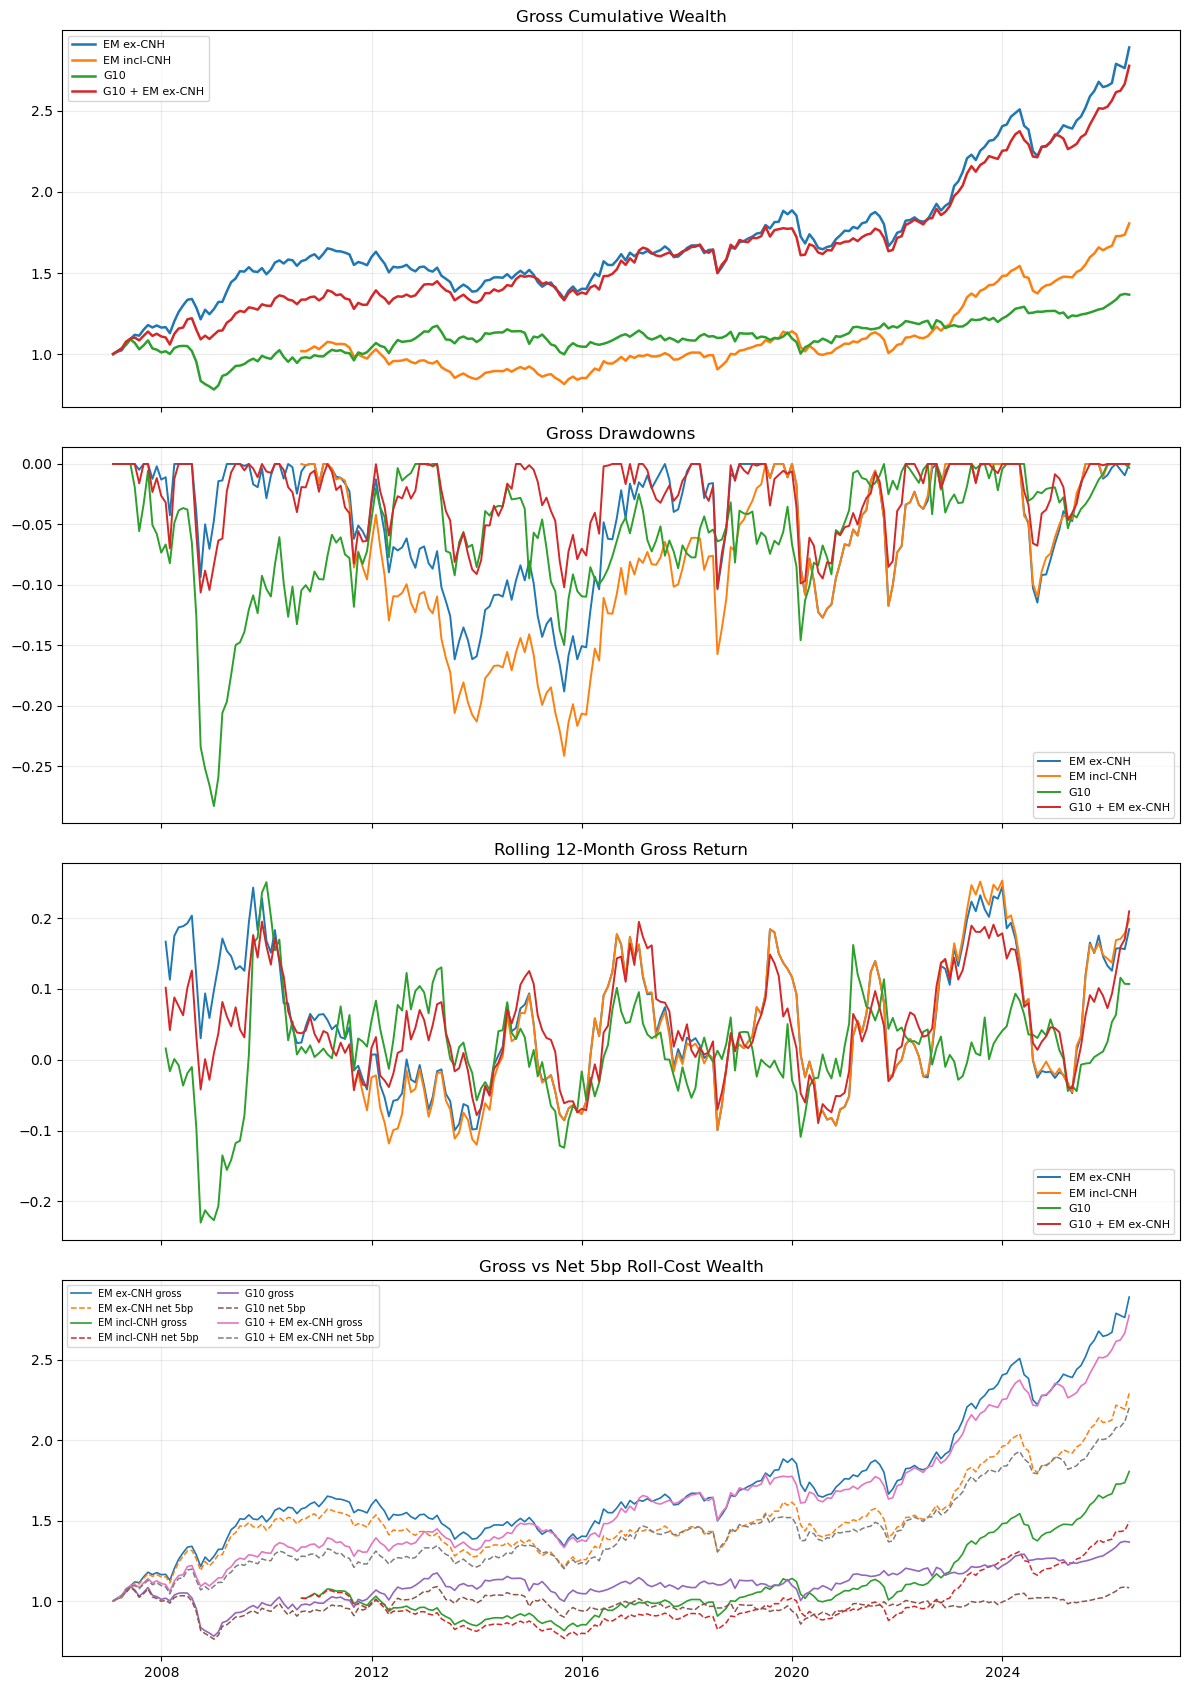

In [13]:
if plt is None or strategy_returns.empty:
    display(Markdown("Plots skipped because matplotlib is unavailable or no strategy returns were created."))
else:
    fig, axes = plt.subplots(4, 1, figsize=(12, 17), sharex=True)
    for strategy, sub in strategy_returns.groupby("strategy"):
        axes[0].plot(sub["month_end"], sub["wealth_gross"], label=strategy, linewidth=1.8)
        axes[1].plot(sub["month_end"], sub["drawdown_gross"], label=strategy, linewidth=1.4)
        axes[2].plot(sub["month_end"], sub["rolling_12m_gross_return"], label=strategy, linewidth=1.4)
    axes[0].set_title("Gross Cumulative Wealth")
    axes[1].set_title("Gross Drawdowns")
    axes[2].set_title("Rolling 12-Month Gross Return")
    for ax in axes[:3]:
        ax.grid(alpha=0.25); ax.legend(fontsize=8)
    # Cost comparison: 5bp for all plus 25bp for EM-oriented strategies.
    for strategy, sub in strategy_returns.groupby("strategy"):
        axes[3].plot(sub["month_end"], (1 + sub["gross_return"]).cumprod(), label=f"{strategy} gross", linewidth=1.2)
        axes[3].plot(sub["month_end"], (1 + sub["net_roll_5bp"]).cumprod(), label=f"{strategy} net 5bp", linewidth=1.1, linestyle="--")
    axes[3].set_title("Gross vs Net 5bp Roll-Cost Wealth")
    axes[3].grid(alpha=0.25); axes[3].legend(fontsize=7, ncol=2)
    plt.tight_layout(); plt.show()


## Basket Composition Diagnostics

The diagnostics below show whether each strategy is dominated by a small set of high-carry currencies. A concentration warning is triggered if TRY, BRL, ZAR, MXN, or HUF are selected very frequently in long baskets.


$$
\text{Turnover}_i = \sum_{t=1}^{T} \left| w_{i,t} - w_{i,t-1} \right|,\qquad w_{i,0} = 0
$$

In [14]:
def composition_diagnostics(weights):
    if weights.empty:
        return pd.DataFrame()
    w = weights.copy()
    w["is_long"] = w["basket"].eq("long_high_carry").astype(float)
    w["is_short"] = w["basket"].eq("short_low_carry").astype(float)
    # Recompute strategy/currency turnover from weights.
    rows=[]
    for strategy, sub in w.groupby("strategy"):
        wide=sub.pivot_table(index="month_end", columns="currency", values="weight", aggfunc="last").fillna(0.0).sort_index()
        turnover_by_ccy=(wide-wide.shift(1).fillna(0.0)).abs().sum()
        stats=(sub.groupby("currency").agg(long_selection_rate=("is_long","mean"), short_selection_rate=("is_short","mean"), average_weight=("weight","mean")).reset_index())
        stats["turnover"] = stats["currency"].map(turnover_by_ccy)
        stats["strategy"] = strategy
        rows.append(stats)
    return pd.concat(rows, ignore_index=True)

composition = composition_diagnostics(strategy_weights)
display(composition.sort_values(["strategy", "long_selection_rate"], ascending=[True, False]).style.format({"long_selection_rate": "{:.1%}", "short_selection_rate": "{:.1%}", "average_weight": "{:.3f}", "turnover": "{:.2f}"}) if not composition.empty else composition)

high_carry_watch = {"TRY", "BRL", "ZAR", "MXN", "HUF"}
concentration = composition[(composition["currency"].isin(high_carry_watch)) & (composition["long_selection_rate"] >= 0.40)].copy() if not composition.empty else pd.DataFrame()
if not concentration.empty:
    display(Markdown("### Concentration warning"))
    display(concentration[["strategy", "currency", "long_selection_rate", "average_weight", "turnover"]].sort_values(["strategy", "long_selection_rate"], ascending=[True, False]))


,currency,long_selection_rate,short_selection_rate,average_weight,turnover,strategy
15,TRY,93.6%,0.0%,0.234,4.25,EM ex-CNH
0,BRL,71.7%,0.0%,0.179,5.75,EM ex-CNH
16,ZAR,56.2%,0.0%,0.141,10.50,EM ex-CNH
8,MXN,43.3%,0.0%,0.108,4.00,EM ex-CNH
6,INR,42.9%,1.7%,0.103,15.75,EM ex-CNH
4,IDR,31.3%,0.0%,0.078,12.50,EM ex-CNH
2,COP,27.9%,10.7%,0.043,9.25,EM ex-CNH
3,HUF,13.0%,30.3%,-0.043,6.00,EM ex-CNH
11,PHP,7.1%,24.1%,-0.042,12.50,EM ex-CNH
1,CLP,6.0%,14.2%,-0.020,7.00,EM ex-CNH


### Concentration warning

,strategy,currency,long_selection_rate,average_weight,turnover
15,EM ex-CNH,TRY,0.935622,0.233906,4.250000
0,EM ex-CNH,BRL,0.716738,0.179185,5.750000
16,EM ex-CNH,ZAR,0.562232,0.140558,10.500000
8,EM ex-CNH,MXN,0.433476,0.108369,4.000000
33,EM incl-CNH,TRY,0.942105,0.235526,2.250000
17,EM incl-CNH,BRL,0.684211,0.171053,3.750000
26,EM incl-CNH,MXN,0.521053,0.130263,4.000000
34,EM incl-CNH,ZAR,0.515789,0.128947,8.500000
68,G10 + EM ex-CNH,TRY,1.000000,0.169957,0.566667
69,G10 + EM ex-CNH,ZAR,0.892704,0.152074,2.566667


## Crisis-Period Analysis

The crisis windows are broad first-pass stress periods. They can be refined later, but they are useful for comparing crash risk across G10 and EM carry.


In [15]:
CRISIS_WINDOWS = [
    {"period": "2008 global financial crisis", "start": "2008-07-31", "end": "2009-03-31"},
    {"period": "2013 taper tantrum", "start": "2013-05-31", "end": "2013-09-30"},
    {"period": "2015 EM / China stress", "start": "2015-06-30", "end": "2016-02-29"},
    {"period": "2020 Covid shock", "start": "2020-02-29", "end": "2020-04-30"},
    {"period": "2022 dollar / rates shock", "start": "2022-01-31", "end": "2022-10-31"},
]

rows=[]
for strategy, s0 in strategy_returns.groupby("strategy"):
    for win in CRISIS_WINDOWS:
        sub=s0[(s0["month_end"]>=pd.Timestamp(win["start"])) & (s0["month_end"]<=pd.Timestamp(win["end"]))].copy()
        r=sub["gross_return"].dropna()
        if r.empty:
            rows.append({"strategy": strategy, **win, "months": 0})
            continue
        worst=sub.loc[sub["gross_return"].idxmin()]
        rows.append({"strategy": strategy, **win, "months": len(r), "period_return": (1+r).prod()-1, "volatility": r.std(ddof=1)*np.sqrt(MONTHS_PER_YEAR) if len(r)>1 else np.nan, "max_drawdown": max_drawdown_initial(r), "worst_month": worst["month_end"].date().isoformat(), "worst_month_return": worst["gross_return"], "long_basket": worst["long_basket"], "short_basket": worst["short_basket"]})
crisis = pd.DataFrame(rows)
display(crisis.style.format({"period_return": "{:.2%}", "volatility": "{:.2%}", "max_drawdown": "{:.2%}", "worst_month_return": "{:.2%}"}) if not crisis.empty else crisis)


,strategy,period,start,end,months,period_return,volatility,max_drawdown,worst_month,worst_month_return,long_basket,short_basket
0,EM ex-CNH,2008 global financial crisis,2008-07-31,2009-03-31,9,3.93%,13.15%,-9.36%,2008-09-30,-5.57%,"BRL, INR, TRY, ZAR","KRW, MYR, PLN, SGD"
1,EM ex-CNH,2013 taper tantrum,2013-05-31,2013-09-30,5,-3.69%,8.26%,-6.64%,2013-07-31,-4.10%,"BRL, IDR, INR, TRY","ILS, MYR, PHP, SGD"
2,EM ex-CNH,2015 EM / China stress,2015-06-30,2016-02-29,9,0.69%,8.98%,-6.97%,2015-08-31,-2.67%,"BRL, IDR, PEN, TRY","COP, HUF, ILS, PLN"
3,EM ex-CNH,2020 Covid shock,2020-02-29,2020-04-30,3,-6.21%,17.93%,-9.27%,2020-02-29,-6.95%,"INR, MXN, TRY, ZAR","HUF, ILS, KRW, SGD"
4,EM ex-CNH,2022 dollar / rates shock,2022-01-31,2022-10-31,10,7.84%,6.21%,-2.13%,2022-10-31,-2.13%,"BRL, HUF, MXN, TRY","ILS, MYR, SGD, THB"
5,EM incl-CNH,2008 global financial crisis,2008-07-31,2009-03-31,0,nan%,nan%,nan%,nan,nan%,nan,nan
6,EM incl-CNH,2013 taper tantrum,2013-05-31,2013-09-30,5,-4.22%,8.45%,-7.18%,2013-07-31,-4.10%,"BRL, IDR, INR, TRY","ILS, MYR, PHP, SGD"
7,EM incl-CNH,2015 EM / China stress,2015-06-30,2016-02-29,9,0.69%,8.98%,-6.97%,2015-08-31,-2.67%,"BRL, IDR, PEN, TRY","COP, HUF, ILS, PLN"
8,EM incl-CNH,2020 Covid shock,2020-02-29,2020-04-30,3,-6.21%,17.93%,-9.27%,2020-02-29,-6.95%,"INR, MXN, TRY, ZAR","HUF, ILS, KRW, SGD"
9,EM incl-CNH,2022 dollar / rates shock,2022-01-31,2022-10-31,10,8.29%,6.19%,-2.10%,2022-10-31,-2.10%,"BRL, HUF, MXN, TRY","CNH, ILS, MYR, THB"


## Save Strategy Outputs

The clean EM panel, strategy returns, and comparison performance table are saved for later notebooks.


In [16]:
strategy_returns.to_parquet(STRATEGY_RETURNS_OUT, index=False)
performance.to_parquet(COMPARISON_OUT, index=False)
print(f"Saved strategy returns to {STRATEGY_RETURNS_OUT.relative_to(ROOT)} ({len(strategy_returns):,} rows)")
print(f"Saved comparison table to {COMPARISON_OUT.relative_to(ROOT)} ({len(performance):,} rows)")


Saved strategy returns to theo/data/processed/em_carry_strategy_returns.parquet (889 rows)
Saved comparison table to theo/data/processed/g10_em_carry_comparison.parquet (28 rows)


## Final Interpretation

This final section summarizes whether EM carry improves on G10 carry, how much roll costs matter, and what should come next.


In [17]:
def pct(x):
    return "n/a" if pd.isna(x) else f"{x:.2%}"

def get_perf(strategy, scenario):
    row = performance[(performance["strategy"].eq(strategy)) & (performance["scenario"].eq(scenario))]
    return row.iloc[0] if not row.empty else None

if performance.empty:
    display(Markdown("No final interpretation available because performance table is empty."))
else:
    g10 = get_perf("G10", "Gross")
    em = get_perf("EM ex-CNH", "Gross")
    em25 = get_perf("EM ex-CNH", "Net roll 25bp")
    combo = get_perf("G10 + EM ex-CNH", "Gross")
    combo25 = get_perf("G10 + EM ex-CNH", "Net roll 25bp")
    notes = f"""
### Final Interpretation Notes

- **Is EM carry stronger than G10?** EM ex-CNH gross annualized return is {pct(em['annualized_return']) if em is not None else 'n/a'} versus G10 gross annualized return of {pct(g10['annualized_return']) if g10 is not None else 'n/a'}. Compare Sharpe ratios as well: EM {em['sharpe_ratio']:.2f} versus G10 {g10['sharpe_ratio']:.2f}.
- **How much disappears after roll costs?** At a 25bp monthly roll-cost stress, EM ex-CNH annualized return is {pct(em25['annualized_return']) if em25 is not None else 'n/a'}. EM carry can look attractive gross, but the higher implementation-cost assumption absorbs a large share of the premium.
- **Crash risk:** EM should be judged by drawdown and skew, not return alone. EM ex-CNH max drawdown is {pct(em['max_drawdown']) if em is not None else 'n/a'} with skewness {em['skewness']:.2f}; this is the compensation-for-crash-risk question in miniature.
- **G10+EM diversification:** G10+EM gross annualized return is {pct(combo['annualized_return']) if combo is not None else 'n/a'} and net 25bp annualized return is {pct(combo25['annualized_return']) if combo25 is not None else 'n/a'}. The combined sample shows whether broader currency diversification offsets EM crash risk and costs.
- **Next step:** The next research step should be option skew / crash-risk filters, volatility targeting, and regime filters. EM carry should not be evaluated only on gross returns because realistic roll costs and crisis drawdowns are central to the economics.
"""
    display(Markdown(notes))



### Final Interpretation Notes

- **Is EM carry stronger than G10?** EM ex-CNH gross annualized return is 5.62% versus G10 gross annualized return of 1.62%. Compare Sharpe ratios as well: EM 0.71 versus G10 0.21.
- **How much disappears after roll costs?** At a 25bp monthly roll-cost stress, EM ex-CNH annualized return is -0.52%. EM carry can look attractive gross, but the higher implementation-cost assumption absorbs a large share of the premium.
- **Crash risk:** EM should be judged by drawdown and skew, not return alone. EM ex-CNH max drawdown is -18.83% with skewness -0.62; this is the compensation-for-crash-risk question in miniature.
- **G10+EM diversification:** G10+EM gross annualized return is 5.40% and net 25bp annualized return is -0.73%. The combined sample shows whether broader currency diversification offsets EM crash risk and costs.
- **Next step:** The next research step should be option skew / crash-risk filters, volatility targeting, and regime filters. EM carry should not be evaluated only on gross returns because realistic roll costs and crisis drawdowns are central to the economics.


## Scope Check

This notebook stops at EM carry extension and G10-versus-EM comparison. It does not add options signals, macro regressions, or machine learning.
